trying a linear regressor as a model

# Load Data

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from pandas.plotting import register_matplotlib_converters
from utils.data_loader import load_parquet, load_csv

# Load only specific columns that you need for analysis
# This will significantly reduce memory usage
columns_needed = ['time', 'orbital_decay']

GFOC_data = load_parquet(columns=columns_needed)
print(GFOC_data.head())


✅ Successfully loaded data with shape: (3157920, 2)
                 time  orbital_decay
0 2023-01-01 00:00:00        16.6730
1 2023-01-01 00:00:20        16.6730
2 2023-01-01 00:00:40        16.6735
3 2023-01-01 00:01:00        16.6740
4 2023-01-01 00:01:20        16.6740


# 1. Take a Subset of the Data

In [2]:
from utils.plot_loader import create_subset
from utils.lag_features import LagFeatures
# =========================== Input ===================================
start_date = '2023-05-01 00:00:00'
end_date = '2023-06-01 00:00:00'
# =====================================================================

subset = create_subset(GFOC_data, start_date, end_date)

# create lag features
subset_lag = LagFeatures(subset[['orbital_decay']], lag_minutes=5, max_lag_hours=48).df
subset_lag = subset_lag.dropna().reset_index(drop=True)
X = subset_lag.drop(columns=['orbital_decay']).values
y = subset_lag['orbital_decay'].values

# 2. Split the Data using timeseriessplit

In [3]:
import numpy as np
from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=5)
all_splits = list(tscv.split(X, y))

train_idx, test_idx = all_splits[0]
X_train, X_test = X[train_idx, :], X[test_idx, :]
y_train, y_test = y[train_idx], y[test_idx]


# 3. Try linear regressor with lags as features

### a) test first split

RMSE: 0.0324
R²: 0.9996


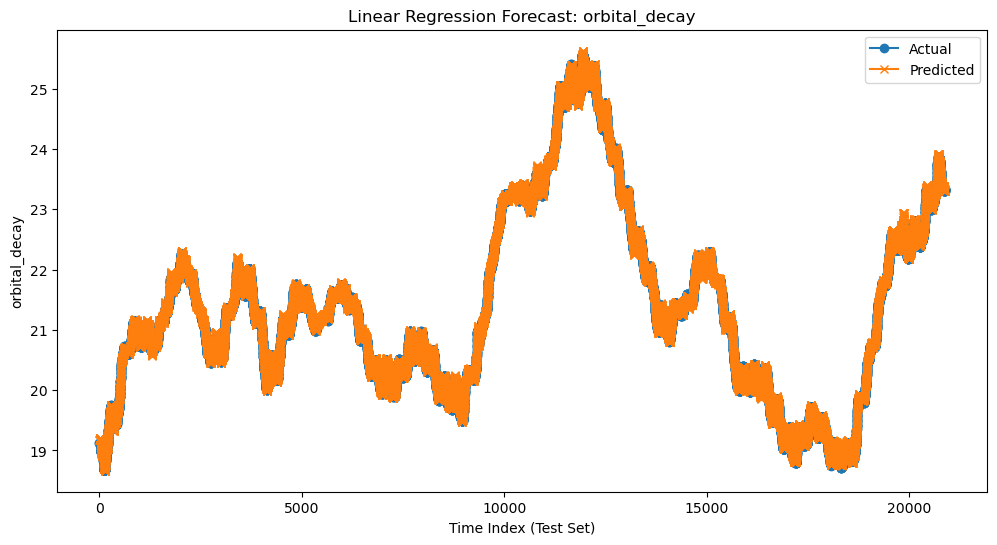

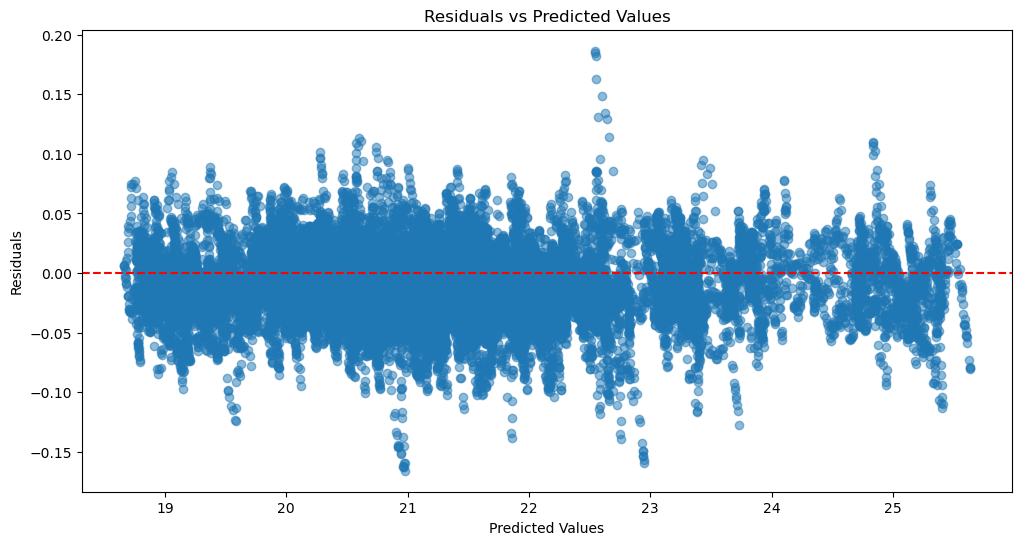

In [4]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

# Initialize and fit model
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluation
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse:.4f}")
print(f"R²: {r2:.4f}")

# Plot results
plt.figure(figsize=(12,6))
plt.plot(y_test, label="Actual", marker='o')
plt.plot(y_pred, label="Predicted", marker='x')
plt.title("Linear Regression Forecast: orbital_decay")
plt.xlabel("Time Index (Test Set)")
plt.ylabel("orbital_decay")
plt.legend()
plt.show()

# Plot residuals
residuals = y_test - y_pred
plt.figure(figsize=(12,6))
plt.scatter(y_pred, residuals, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.title("Residuals vs Predicted Values")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.show()


In [5]:
from sklearn.model_selection import cross_val_score

cv_mape_scores = -cross_val_score(
    model, X, y, cv=tscv, scoring="neg_mean_absolute_percentage_error"
)
cv_mape_scores

array([0.00119105, 0.0011175 , 0.00129789, 0.00120418, 0.00113176])

### b) Loop through all splits

In [6]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

rmse_scores = []
r2_scores = []

# Loop through each split
for i, (train_idx, test_idx) in enumerate(all_splits):
    X_train, X_test = X[train_idx, :], X[test_idx, :]
    y_train, y_test = y[train_idx], y[test_idx]

    # Train model
    model = LinearRegression()
    model.fit(X_train, y_train)

    # Predict
    y_pred = model.predict(X_test)

    # Evaluate
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    rmse_scores.append(rmse)
    r2_scores.append(r2)

    print(f"Fold {i+1}: RMSE = {rmse:.4f}, R² = {r2:.4f}")

# Summary across folds
print("\n--- Cross-Validation Results ---")
print(f"Average RMSE: {np.mean(rmse_scores):.4f} ± {np.std(rmse_scores):.4f}")
print(f"Average R²: {np.mean(r2_scores):.4f} ± {np.std(r2_scores):.4f}")


Fold 1: RMSE = 0.0324, R² = 0.9996
Fold 2: RMSE = 0.0262, R² = 0.9999
Fold 3: RMSE = 0.0295, R² = 1.0000
Fold 4: RMSE = 0.0248, R² = 0.9998
Fold 5: RMSE = 0.0225, R² = 0.9998

--- Cross-Validation Results ---
Average RMSE: 0.0271 ± 0.0035
Average R²: 0.9998 ± 0.0001


### Interpretation

The results look too good.

Problems:
- X_test contains recent past values of orbital_decay for the test period.
- Linear regression can almost perfectly predict the next value because the series changes very slowly (header example: 16.6730 → 16.6740 over minutes).
- Effectively, the model is doing interpolation, not real forecasting. This explains the absurdly low RMSE and R² ~ 0.9999.

### Multistep Forecast

true prediction, no cheating!

RMSE: 0.3489
R²: -4.7343


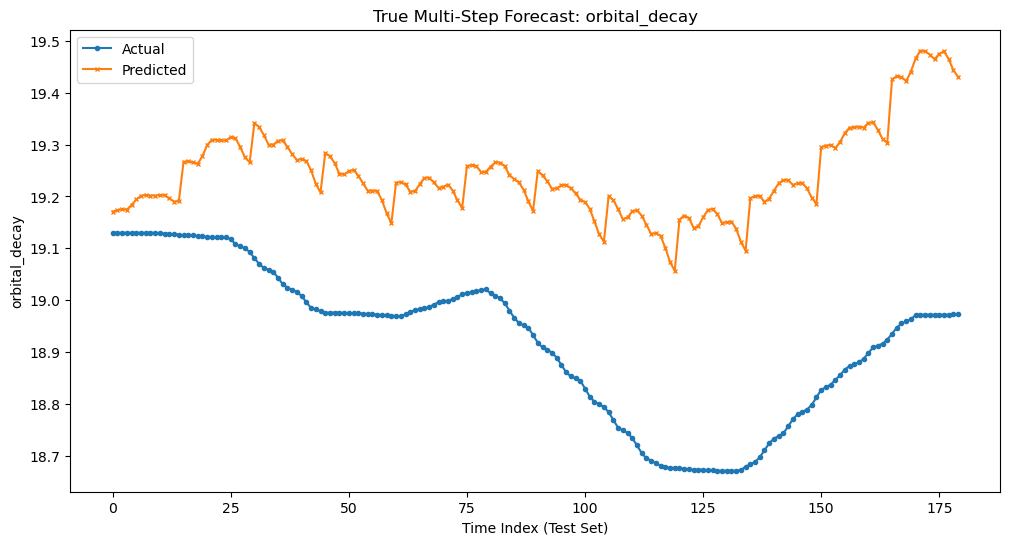

In [7]:
tscv = TimeSeriesSplit(n_splits=5, gap=0) # gap of 48 hours with 20 second intervals
all_splits = list(tscv.split(X, y))

train_idx, test_idx = all_splits[0]
X_train, X_test = X[train_idx, :], X[test_idx, :]
y_train, y_test = y[train_idx], y[test_idx]

# =================== Train model ===================
model = LinearRegression()
model.fit(X_train, y_train)

# =================== Multi-step forecast ===================
# We will recursively predict test set using our own previous predictions

# Compute lag indices in terms of samples
lag_indices = np.arange(-15, -48*60*3-1, -15)

# Initialize history with enough past data to cover all lags
history = list(y[(test_idx[0]+lag_indices.min()):test_idx[0]])  # all points needed to cover largest lag

predictions = []

forecast_horizon = 1*60*3  # 1 hour ahead with 20 second intervals

for i in range(len(y_test[:forecast_horizon])):
    # pick correct lagged values from history
    x_input = np.array([history[lag] for lag in lag_indices]).reshape(1, -1)
    
    y_hat = model.predict(x_input)[0]
    predictions.append(y_hat)
    
    # append prediction to history for future lags
    history.append(y_hat)


predictions = np.array(predictions)

# =================== Evaluation ===================
mse = mean_squared_error(y_test[:forecast_horizon], predictions)
rmse = np.sqrt(mse)
r2 = r2_score(y_test[:forecast_horizon], predictions)

print(f"RMSE: {rmse:.4f}")
print(f"R²: {r2:.4f}")

# =================== Plots ===================
plt.figure(figsize=(12,6))
plt.plot(y_test[:forecast_horizon], label="Actual", marker='o', markersize=3)
plt.plot(predictions, label="Predicted", marker='x', markersize=3)
plt.title("True Multi-Step Forecast: orbital_decay")
plt.xlabel("Time Index (Test Set)")
plt.ylabel("orbital_decay")
plt.legend()
plt.show()

This looks better, meaning that it looks worse, but this is expected for such a simple model (that does not cheat).

In [8]:
rmse_scores = []
r2_scores = []

# Compute lag indices in terms of samples
lag_indices = np.arange(-15, -48*60*3-1, -15)

# Loop through each split
for k, (train_idx, test_idx) in enumerate(all_splits):
    X_train, X_test = X[train_idx, :], X[test_idx, :]
    y_train, y_test = y[train_idx], y[test_idx]

    # Train model
    model = LinearRegression()
    model.fit(X_train, y_train)

    # Predict
    # Initialize history with enough past data to cover all lags
    history = list(y[(test_idx[0]+lag_indices.min()):test_idx[0]])  # all points needed to cover largest lag

    predictions = []

    for i in range(len(y_test)):
        # pick correct lagged values from history
        x_input = np.array([history[lag] for lag in lag_indices]).reshape(1, -1)
        
        y_hat = model.predict(x_input)[0]
        predictions.append(y_hat)
        
        # append prediction to history for future lags
        history.append(y_hat)


    predictions = np.array(predictions)

    # Evaluate
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    r2 = r2_score(y_test, predictions)

    rmse_scores.append(rmse)
    r2_scores.append(r2)

    print(f"Fold {k+1}: RMSE = {rmse:.4f}, R² = {r2:.4f}")

# Summary across folds
print("\n--- Cross-Validation Results ---")
print(f"Average RMSE: {np.mean(rmse_scores):.4f} ± {np.std(rmse_scores):.4f}")
print(f"Average R²: {np.mean(r2_scores):.4f} ± {np.std(r2_scores):.4f}")

Fold 1: RMSE = 49.3011, R² = -1038.3596
Fold 2: RMSE = 4.5860, R² = -3.2518
Fold 3: RMSE = 4.7240, R² = -0.0504
Fold 4: RMSE = 3.6235, R² = -3.9649
Fold 5: RMSE = 1.5907, R² = 0.0370

--- Cross-Validation Results ---
Average RMSE: 12.7651 ± 18.3023
Average R²: -209.1180 ± 414.6240


# 3.5 improve code and plots for forecasting

RMSE: 3.1448
R²: -35.8064


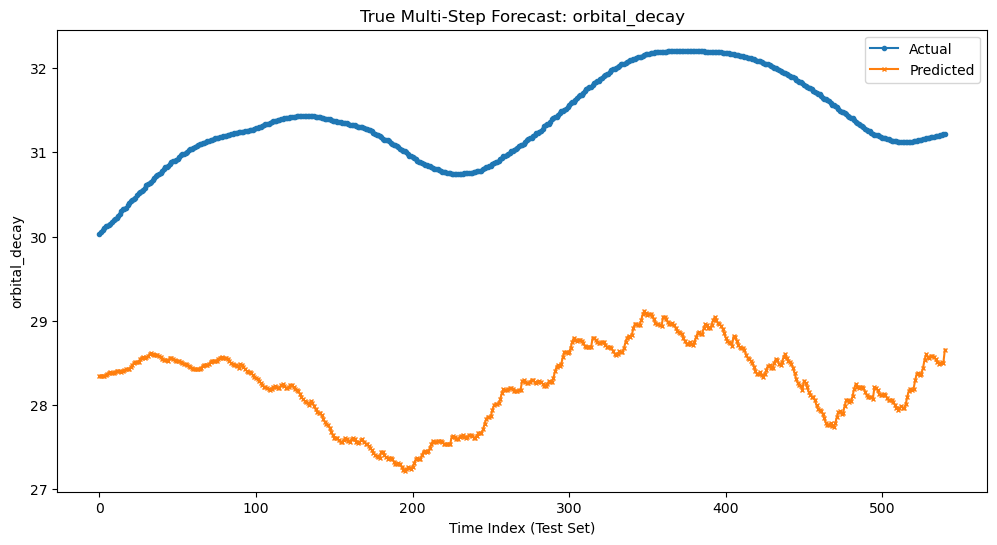

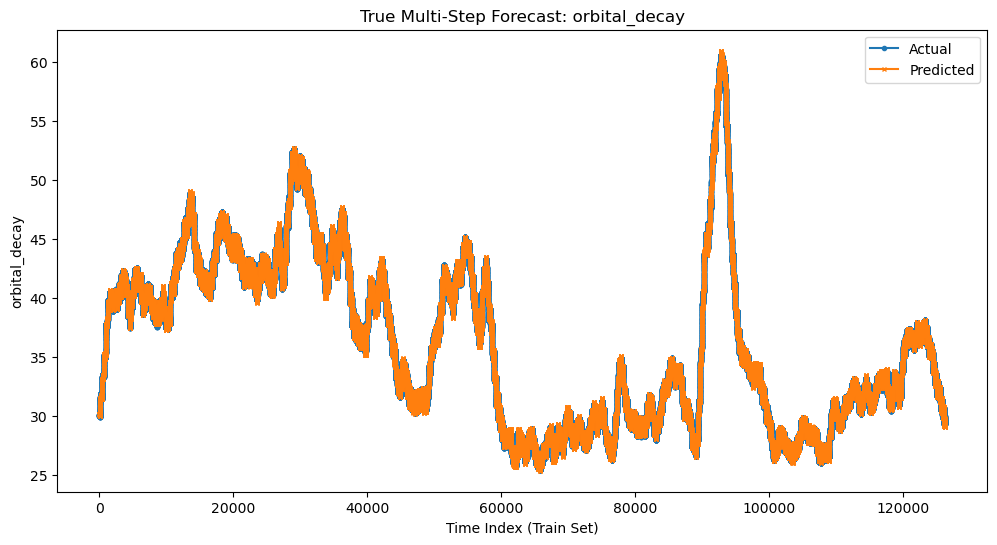

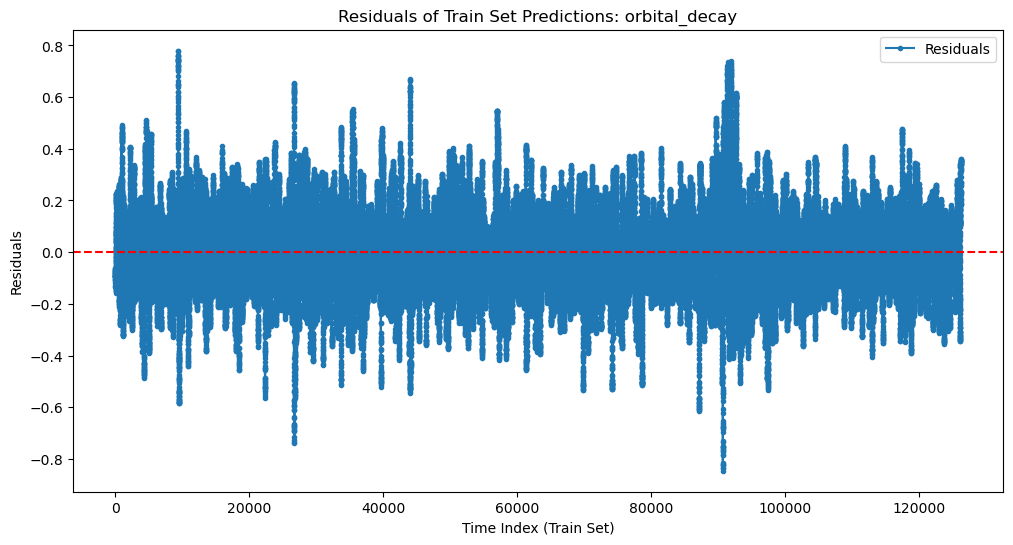

In [11]:
from utils.plot_loader import create_subset
from utils.lag_features import LagFeatures
# =========================== Input ===================================
start_date = '2023-03-01 00:00:00'
end_date = '2023-04-01 00:00:00'
lag_minutes = 15
max_lag_hours = 40
forecast_horizon = 3  # in hours
# =====================================================================

subset = create_subset(GFOC_data, start_date, end_date)
time = subset['time'].values

# create lag features
subset_lag = LagFeatures(subset[['orbital_decay']], lag_minutes=lag_minutes, max_lag_hours=max_lag_hours).df
subset_lag = subset_lag.dropna().reset_index(drop=True)
X = subset_lag.drop(columns=['orbital_decay']).values
y = subset_lag['orbital_decay'].values

train_idx = len(y) - forecast_horizon*60*3 - 1
X_train = X[:train_idx, :]
y_train, y_test = y[:train_idx], y[train_idx:]
t_train, t_test = time[:train_idx], time[train_idx:]

# =================== Train model ===================
model = LinearRegression()
model.fit(X_train, y_train)

# =================== Multi-step forecast ===================
# We will recursively predict test set using our own previous predictions

# Compute lag indices in terms of samples
lag_indices = np.arange(-lag_minutes*3, -max_lag_hours*60*3-1, -lag_minutes*3)

# Initialize history with enough past data to cover all lags
history = list(y[(test_idx[0]+lag_indices.min()):test_idx[0]])  # all points needed to cover largest lag

predictions = []

for i in range(len(y_test)):
    # pick correct lagged values from history
    x_input = np.array([history[lag] for lag in lag_indices]).reshape(1, -1)
    
    y_hat = model.predict(x_input)[0]
    predictions.append(y_hat)
    
    # append prediction to history for future lags
    history.append(y_hat)


predictions = np.array(predictions)

# =================== Evaluation ===================
mse = mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, predictions)

print(f"RMSE: {rmse:.4f}")
print(f"R²: {r2:.4f}")

# =================== Plots ===================
plt.figure(figsize=(12,6))
plt.plot(y_test, label="Actual", marker='o', markersize=3)
plt.plot(predictions, label="Predicted", marker='x', markersize=3)
plt.title("True Multi-Step Forecast: orbital_decay")
plt.xlabel("Time Index (Test Set)")
plt.ylabel("orbital_decay")
plt.legend()
plt.show()

y_train_pred = model.predict(X_train)
plt.figure(figsize=(12,6))
plt.plot(y_train, label="Actual", marker='o', markersize=3)
plt.plot(y_train_pred, label="Predicted", marker='x', markersize=3)
plt.title("True Multi-Step Forecast: orbital_decay")
plt.xlabel("Time Index (Train Set)")
plt.ylabel("orbital_decay")
plt.legend()
plt.show()

# Plot residuals
residuals = y_train - y_train_pred
plt.figure(figsize=(12,6))
plt.plot(residuals, label="Residuals", marker='o', markersize=3)
plt.title("Residuals of Train Set Predictions: orbital_decay")
plt.xlabel("Time Index (Train Set)")
plt.ylabel("Residuals")
plt.axhline(0, color='red', linestyle='--')
plt.legend()
plt.show()

# 4. Experiment with different simple models